## Check Extraction Results

After extraction completes:
- Tiles are saved to: `/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/tiles/`
- TFRecords are saved to: `/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/tfrecords/299px_302um/`
- An extraction report PDF will be generated in the tfrecords directory showing:
  - Number of tiles extracted per slide
  - Quality control filtering results
  - Whitespace filtering statistics

## Tile Extraction

Extract tiles from the 17 Exp2 slides using:
- **299px × 302μm** tiles (approx 10x magnification)
- **ROI method**: Extract only within Anna's manual annotations
- **Whitespace filtering**: Remove tiles with >95% whitespace
- **Quality control**: Use Gaussian blur detection and Otsu thresholding to remove low-quality tiles

In [2]:
import slideflow as sf
from slideflow.slide import qc

# Load the Exp2_Demo project
PROJECT_PATH = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo"
project = sf.load_project(PROJECT_PATH)

In [ ]:
# Load dataset filtered to only Exp2_Dataset source (17 slides)
dataset = project.dataset(sources=['Exp2_Dataset'])

In [ ]:
dataset.summary()

In [ ]:
# Extract tiles from the 17 Exp2 slides
# annotations.csv now contains ONLY the 17 Exp2 slides, so no filtering needed
project.extract_tiles(
    tile_px=299,              # Tile size in pixels
    tile_um=302,              # Tile size in microns (approx 10x magnification)
    roi_method='inside',      # Extract only within ROI annotations
    whitespace_fraction=0.95, # Filter out tiles with >95% whitespace
    source=['Exp2_Dataset'],
    qc=[qc.GaussianV2(), qc.Otsu()]  # Quality control filters
)

In [ ]:
# # Extract tiles from Exp2 slides
# project.extract_tiles(
#     tile_px=299,              # Tile size in pixels
#     tile_um=302,              # Tile size in microns (approx 10x magnification)
#     roi_method='inside',      # Extract only within ROI annotations
#     whitespace_fraction=0.95, # Filter out tiles with >95% whitespace
#     qc=[qc.GaussianV2(), qc.Otsu()],  # Quality control filters
#     source=['Exp2_Dataset']
# )

## Feature Extraction

Using **Virchow** as the foundation model — a DINOv2 model pretrained on 1.5M whole slide images that outputs 2560-dim feature vectors per tile.

Your tiles were extracted at 299px × 302μm, but Virchow expects 224px input. The `resize=True` parameter in `DatasetFeatures` handles this automatically.

In [5]:
import torch

# Verify GPU is available (required for feature extraction)
print('GPU available:', torch.cuda.is_available())
print('GPU name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')

# List all available feature extractors
print('\nAvailable feature extractors:')
print(sf.model.list_extractors())

GPU available: True
GPU name: NVIDIA RTX A5000

Available feature extractors:
['inception_resnet_v2_imagenet', 'alexnet_imagenet', 'mobilenet_v3_small_imagenet', 'mobilenet_imagenet', 'resnet101_v2_imagenet', 'resnet18_imagenet', 'squeezenet_imagenet', 'resnet152_imagenet', 'wide_resnet50_2_imagenet', 'inception_imagenet', 'mobilenet_v3_large_imagenet', 'resnet152_v2_imagenet', 'vit', 'resnet101_imagenet', 'dinov2', 'resnext50_32x4d_imagenet', 'vgg16_imagenet', 'shufflenet_imagenet', 'mnasnet_imagenet', 'nasnet_large_imagenet', 'simclr', 'xception_imagenet', 'virchow', 'resnet50_imagenet', 'mobilenet_v2_imagenet', 'googlenet_imagenet', 'vgg19_imagenet', 'resnet50_v2_imagenet', 'densenet_imagenet']


In [13]:
# Build Virchow feature extractor
# resize=True tells the extractor to automatically resize input tiles to 224px
EXTRACTOR_NAME = 'virchow'
MODEL_WEIGHTS = '/home/stanna/labshare/MODELS/virchow/pytorch_model.bin'

extractor = sf.build_feature_extractor(
    EXTRACTOR_NAME,
    weights=MODEL_WEIGHTS,
    resize=True
)
print(f'Extractor built: {extractor}')

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/model/extractors/virchow.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(weights, 

Extractor built: <VirchowFeatures n_features=2560, n_classes=0>


In [12]:
# Reload dataset specifying the tile dimensions used during extraction
# This tells slideflow where to find the tfrecords (299px_302um/)
dataset = project.dataset(
    sources=['Exp2_Dataset'],
    tile_px=299,
    tile_um=302
)
print(f'Slides loaded: {len(dataset.slides())}')
dataset.summary()

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Slides loaded: 17
Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │ 299                                                                    │
│ Tile size (um):     │ 302                                                                    │
│ Slides:             │ 17                                                                     │
│ Patients:           │ 17                                                                     │
│ Slides with ROIs:   │ 17                                                                     │
│ Patients with ROIs: │ 17                                                                     │
╘═════════════════════╧════════════════════════════════════════════════════════════════════════╛

Filters:
╒═══════════════╤════╕
│ Filters:      │ {} │
├───────────────┼────┤
│ Filter Blank: │ []

In [ ]:
# Generate features using Virchow and save as .pt bags
# Each .pt file = all tile features for one slide, saved directly to outdir
FEATURE_OUTDIR = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow'

dataset.generate_feature_bags(extractor, outdir=FEATURE_OUTDIR)
print(f'Feature bags saved to: {FEATURE_OUTDIR}')

[03:14:33] INFO     Using feature extractor: virchow

Feature bags saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow


## UMAP Clustering & Visualization

Now we'll:
1. Load all tile features from .pt bags
2. Map each tile to its ROI label using point-in-polygon testing
3. Consolidate labels to 3 classes: **Benign**, **Dysplasia**, **Carcinoma**
4. Run UMAP to reduce 2560-dim → 2D
5. Visualize colored by tissue class

In [1]:
import numpy as np
import pandas as pd
import torch
from shapely.geometry import Point, Polygon
from pathlib import Path
import umap
import matplotlib.pyplot as plt
import slideflow as sf

# Paths
FEATURE_DIR = Path('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow')
ROI_DIR = Path('/home/stanna/labshare/PROJECTS/PDCD10/rois/anna')

# The 17 Exp2 slides
SLIDES = ['AG985F', 'AG986F', 'AG987F', 'AG991M', 'AH063F', 'AH073M', 'AH074M', 
          'AH139F', 'AH141F', 'AH142F', 'AH145M', 'AH146M', 'AH210F', 'AH211F', 
          'AH212F', 'AH213F', 'AH215M']

# Label mapping: consolidate to 3 classes
LABEL_MAP = {
    'Benign': 'Benign',
    'Dysplasia': 'Dysplasia',
    'Carcinoma': 'Carcinoma',
    'Invasive carcinoma': 'Carcinoma',
    'Detached papillary carcinoma vs detached papilloma with dysplasia': 'Carcinoma'
}

print(f"Feature directory: {FEATURE_DIR}")
print(f"ROI directory: {ROI_DIR}")
print(f"Number of slides: {len(SLIDES)}")

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature directory: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/virchow
ROI directory: /home/stanna/labshare/PROJECTS/PDCD10/rois/anna
Number of slides: 17


In [12]:
def load_roi_polygons(slide_name):
    """Load ROI CSV and return list of (Polygon, label) tuples."""
    roi_path = ROI_DIR / f"{slide_name}.csv"
    if not roi_path.exists():
        print(f"Warning: ROI file not found for {slide_name}")
        return []
    
    df = pd.read_csv(roi_path)
    polygons = []
    
    # Group by roi_name to get each polygon's vertices
    for roi_name, group in df.groupby('roi_name'):
        coords = list(zip(group['x_base'], group['y_base']))
        if len(coords) >= 3:  # Need at least 3 points for a polygon
            try:
                poly = Polygon(coords)
                if poly.is_valid:
                    label = group['label'].iloc[0]  # All rows for same ROI have same label
                    polygons.append((poly, label))
            except:
                pass
    
    return polygons

def get_tile_label(x, y, polygons):
    """Find which ROI polygon contains the tile and return its label."""
    point = Point(x, y)
    for poly, label in polygons:
        if poly.contains(point):
            return LABEL_MAP.get(label, label)
    return None  # Tile not in any ROI (shouldn't happen with roi_method='inside')

# Test on one slide
test_polys = load_roi_polygons('AG985F')
print(f"AG985F has {len(test_polys)} ROI polygons")
print(f"Labels in AG985F: {set(p[1] for p in test_polys)}")

AG985F has 17 ROI polygons
Labels in AG985F: {'Dysplasia', 'Invasive carcinoma', 'Benign'}


In [3]:
# Load all features and map to labels
all_features = []
all_labels = []
all_slides = []

for slide in SLIDES:
    # Load feature bag (.pt file)
    pt_path = FEATURE_DIR / f"{slide}.pt"
    idx_path = FEATURE_DIR / f"{slide}.index.npz"
    
    if not pt_path.exists() or not idx_path.exists():
        print(f"Skipping {slide}: files not found")
        continue
    
    # Load features (shape: n_tiles x 2560)
    features = torch.load(pt_path).numpy()
    
    # Load tile coordinates (shape: n_tiles x 2)
    idx = np.load(idx_path)
    coords = idx['arr_0']  # (x, y) coordinates for each tile
    
    # Load ROI polygons for this slide
    polygons = load_roi_polygons(slide)
    
    # Map each tile to its label
    slide_labels = []
    for i, (x, y) in enumerate(coords):
        label = get_tile_label(x, y, polygons)
        slide_labels.append(label)
    
    # Store features and labels (skip tiles without labels)
    for i, label in enumerate(slide_labels):
        if label is not None:
            all_features.append(features[i])
            all_labels.append(label)
            all_slides.append(slide)
    
    n_labeled = sum(1 for l in slide_labels if l is not None)
    print(f"{slide}: {len(features)} tiles, {n_labeled} labeled")

# Convert to arrays
all_features = np.array(all_features)
all_labels = np.array(all_labels)
all_slides = np.array(all_slides)

print(f"\nTotal: {len(all_features)} tiles with labels")
print(f"Label distribution: {pd.Series(all_labels).value_counts().to_dict()}")

/tmp/ipykernel_31419/3964806194.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()


AG985F: 113 tiles, 113 labeled


/tmp/ipykernel_31419/3964806194.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()
/tmp/ipykernel_31419/3964806194.py:16: FutureWarn

AG986F: 87 tiles, 87 labeled
AG987F: 91 tiles, 91 labeled
AG991M: 61 tiles, 61 labeled


/tmp/ipykernel_31419/3964806194.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()
/tmp/ipykernel_31419/3964806194.py:16: FutureWarn

...

AH212F: 104 tiles, 104 labeled


/tmp/ipykernel_31419/3964806194.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()


AH213F: 196 tiles, 196 labeled


/tmp/ipykernel_31419/3964806194.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()


AH215M: 184 tiles, 184 labeled

Total: 2033 tiles with labels
Label distribution: {'Dysplasia': 1137, 'Benign': 453, 'Carcinoma': 443}


In [5]:
# Run UMAP to reduce 2560-dim features to 2D
print("Running UMAP (this may take a minute)...")

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embedding = reducer.fit_transform(all_features)
print(f"UMAP complete! Embedding shape: {embedding.shape}")

Running UMAP (this may take a minute)...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete! Embedding shape: (2033, 2)


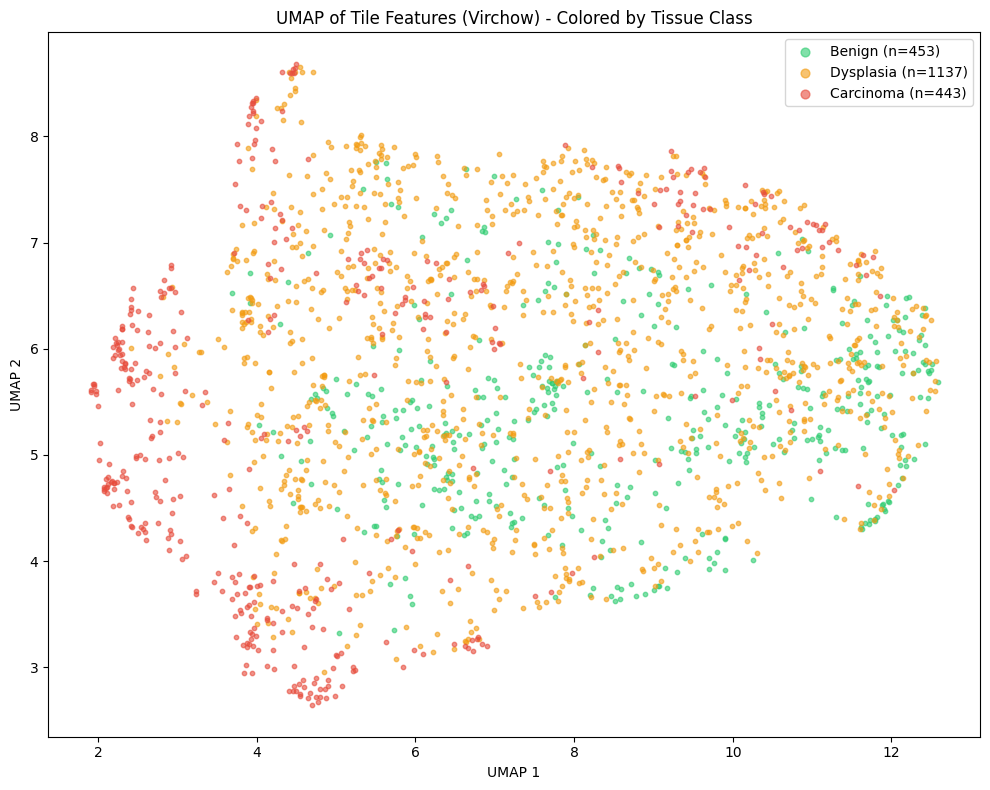

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_by_class.png


In [6]:
# Plot UMAP colored by tissue class
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each class
colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}

for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    mask = all_labels == label
    ax.scatter(
        embedding[mask, 0], 
        embedding[mask, 1], 
        c=colors[label], 
        label=f'{label} (n={mask.sum()})',
        alpha=0.6,
        s=10
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of Tile Features (Virchow) - Colored by Tissue Class')
ax.legend(loc='best', markerscale=2)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_by_class.png', dpi=150)
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_by_class.png")

/tmp/ipykernel_1061225/1341351588.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_slides))


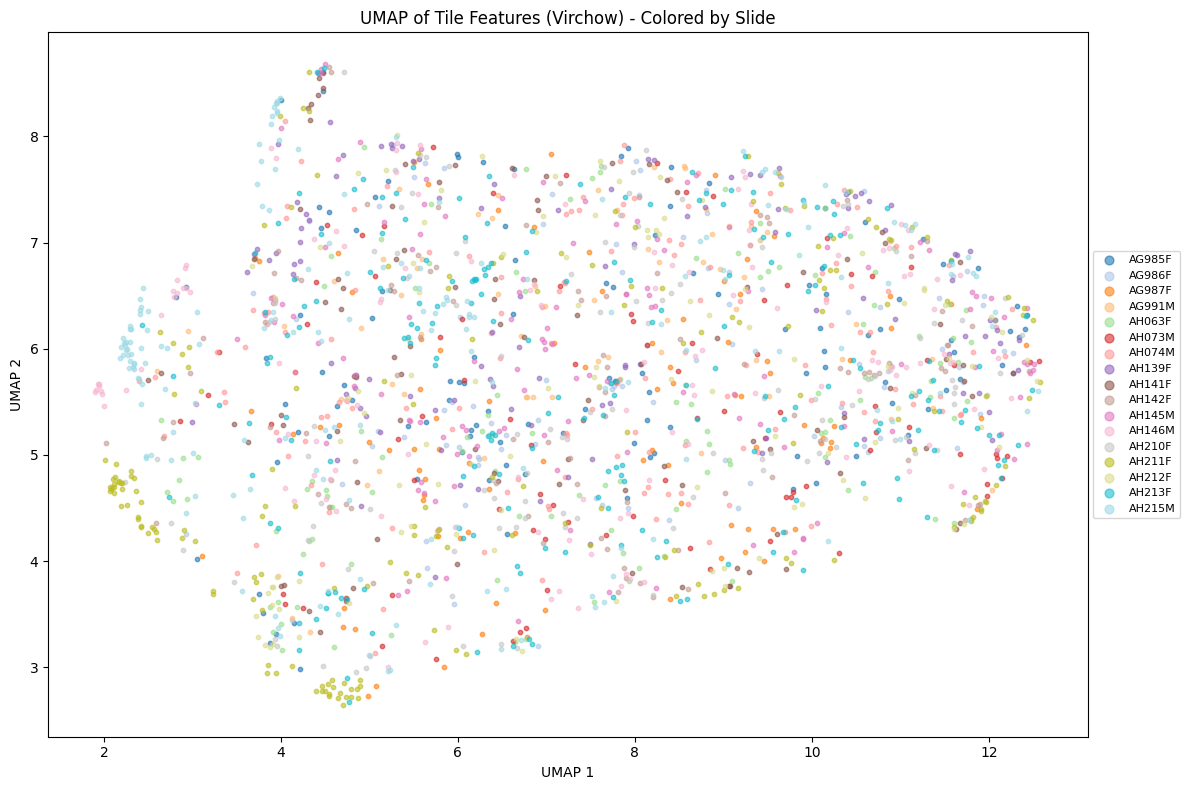

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_by_slide.png


In [8]:
# Optional: Plot UMAP colored by slide (to check for batch effects)
fig, ax = plt.subplots(figsize=(12, 8))

unique_slides = np.unique(all_slides)
cmap = plt.cm.get_cmap('tab20', len(unique_slides))

for i, slide in enumerate(unique_slides):
    mask = all_slides == slide
    ax.scatter(
        embedding[mask, 0], 
        embedding[mask, 1], 
        c=[cmap(i)], 
        label=slide,
        alpha=0.6,
        s=10
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of Tile Features (Virchow) - Colored by Slide')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_by_slide.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_by_slide.png")

## UMAP with Downsampling

The Dysplasia class is overrepresented (n=1137 vs ~450 for others). We'll downsample to balance the classes so no single class dominates the visualization.

In [7]:
# Create DataFrame from existing arrays for easy manipulation
results_df = pd.DataFrame({
    'label': all_labels,
    'slide': all_slides
})
# Store feature indices to retrieve them after downsampling
results_df['feature_idx'] = np.arange(len(all_features))

print("Current class distribution:")
print(results_df['label'].value_counts())

# Target size (match smallest class)
TARGET_N = min(results_df['label'].value_counts())
print(f"\nDownsampling to {TARGET_N} per class...")

# Downsample each class to target
balanced_dfs = []
for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    class_df = results_df[results_df['label'] == label]
    if len(class_df) > TARGET_N:
        class_df = class_df.sample(n=TARGET_N, random_state=42)
    balanced_dfs.append(class_df)

balanced_df = pd.concat(balanced_dfs, ignore_index=True)

# Extract balanced features using the indices
balanced_indices = balanced_df['feature_idx'].values
balanced_features = all_features[balanced_indices]
balanced_labels = balanced_df['label'].values
balanced_slides = balanced_df['slide'].values

print(f"\nBalanced dataset: {len(balanced_df)} tiles")
print(balanced_df['label'].value_counts())

Current class distribution:
label
Dysplasia    1137
Benign        453
Carcinoma     443
Name: count, dtype: int64

Downsampling to 443 per class...

Balanced dataset: 1329 tiles
label
Benign       443
Dysplasia    443
Carcinoma    443
Name: count, dtype: int64


In [20]:
balanced_labels

array(['Benign', 'Benign', 'Benign', ..., 'Carcinoma', 'Carcinoma',
       'Carcinoma'], dtype=object)

In [8]:
# Re-run UMAP on balanced features
print("Running UMAP on balanced data...")

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

balanced_embedding = reducer.fit_transform(balanced_features)
print(f"UMAP complete! Shape: {balanced_embedding.shape}")

Running UMAP on balanced data...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete! Shape: (1329, 2)


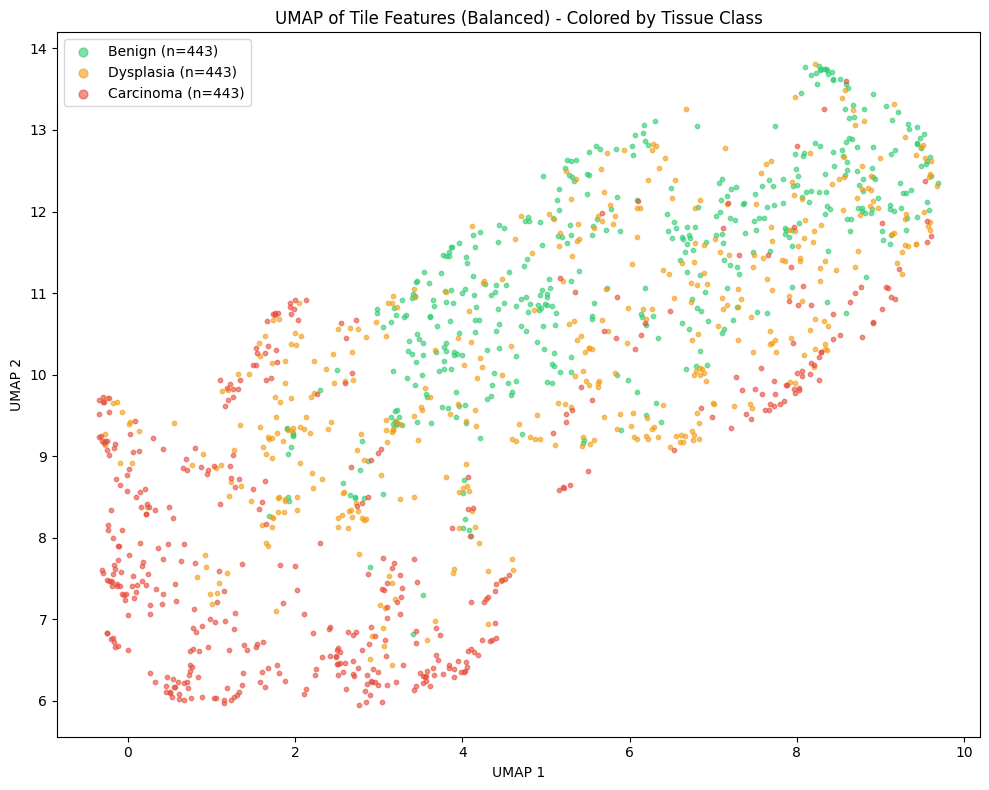

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_balanced_by_class.png


In [9]:
# Plot balanced UMAP colored by tissue class
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}

for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    mask = balanced_labels == label
    ax.scatter(
        balanced_embedding[mask, 0], 
        balanced_embedding[mask, 1], 
        c=colors[label], 
        label=f'{label} (n={mask.sum()})',
        alpha=0.6,
        s=10
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of Tile Features (Balanced) - Colored by Tissue Class')
ax.legend(loc='best', markerscale=2)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_balanced_by_class.png', dpi=150)
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_balanced_by_class.png")

/tmp/ipykernel_1061225/2307685609.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_slides))


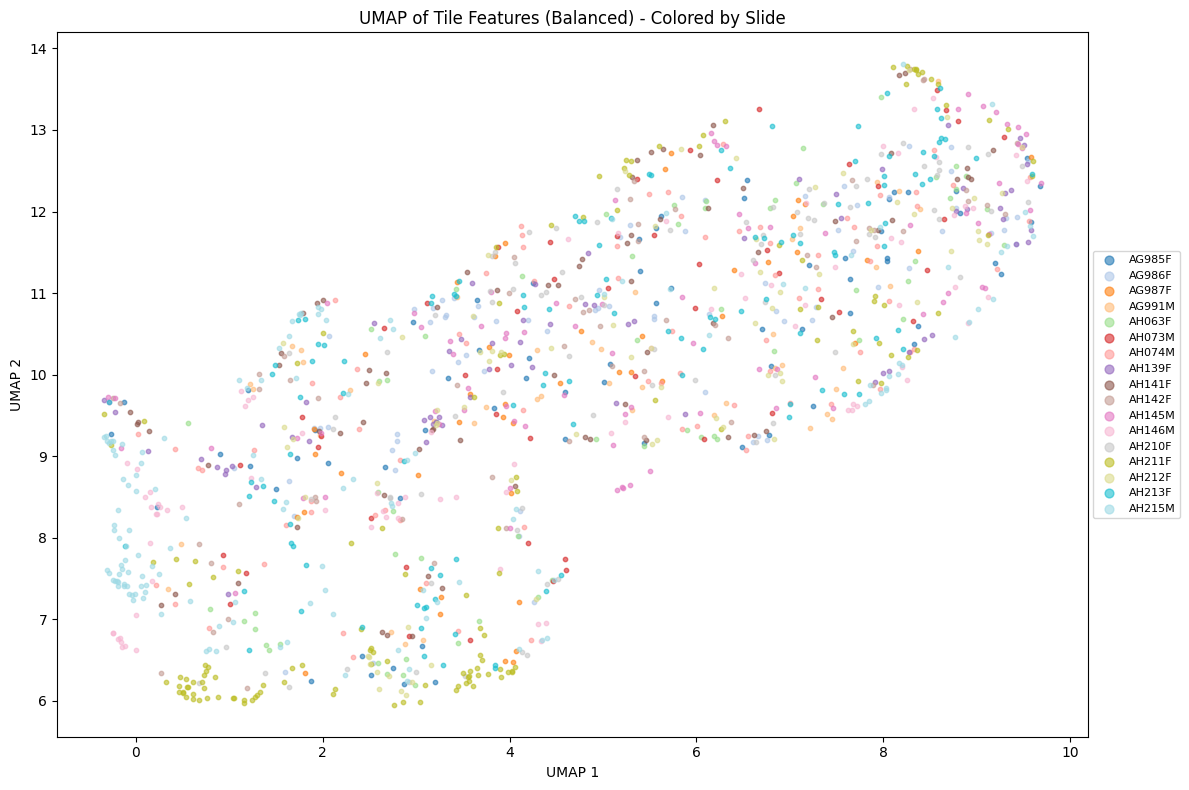

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_balanced_by_slide.png


In [19]:
# Plot balanced UMAP colored by slide (batch effect check)
fig, ax = plt.subplots(figsize=(12, 8))

unique_slides = np.unique(balanced_slides)
cmap = plt.cm.get_cmap('tab20', len(unique_slides))

for i, slide in enumerate(unique_slides):
    mask = balanced_slides == slide
    ax.scatter(
        balanced_embedding[mask, 0], 
        balanced_embedding[mask, 1], 
        c=[cmap(i)], 
        label=slide,
        alpha=0.6,
        s=10
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of Tile Features (Balanced) - Colored by Slide')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_balanced_by_slide.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_balanced_by_slide.png")

In [10]:
import joblib

# Save the fitted UMAP reducer so it persists across kernel restarts
# Needed for projecting Grayson's data with reducer.transform()
REDUCER_PATH = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_reducer_balanced.joblib'
joblib.dump(reducer, REDUCER_PATH)
print(f"Reducer saved to: {REDUCER_PATH}")

# To reload later:
# reducer = joblib.load(REDUCER_PATH)

Reducer saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_reducer_balanced.joblib


---

## Projecting Grayson's Severity Grades onto Anna's UMAP

A second pathologist (Grayson) annotated **9 of the same 17 slides** with finer severity grading:
**Benign → Mild → Moderate → Severe → Carcinoma**

We will:
1. Extract tiles within Grayson's ROI boundaries
2. Run Virchow feature extraction on those tiles
3. Use `reducer.transform()` to project them onto Anna's existing UMAP
4. Visualize to see if severity grades form a progression gradient

If mild dysplasia lands near the Benign region and severe dysplasia lands near Carcinoma, this is independent evidence of a biological progression in the feature space.

### Step 1: Load Project with Grayson Source & Extract Tiles

We added a `Grayson_Dataset` source to `datasets.json` pointing to Grayson's ROI directory with separate output directories. The same slide images are used — only the ROI annotations differ.

In [11]:
import slideflow as sf
from slideflow.slide import qc

# Reload the project (picks up the new Grayson_Dataset source)
PROJECT_PATH = "/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo"
project = sf.load_project(PROJECT_PATH)

# Load dataset filtered to ONLY Grayson's source (9 slides)
grayson_dataset = project.dataset(
    sources=['Grayson_Dataset'],
    filters={'source': ['Grayson_Dataset']}
)
print(f"Grayson slides: {grayson_dataset.slides()}")
print(f"Number of slides: {len(grayson_dataset.slides())}")
grayson_dataset.summary()

Grayson slides: ['AG985F', 'AG986F', 'AG987F', 'AG991M', 'AH063F', 'AH073M', 'AH074M', 'AH139F', 'AH141F']
Number of slides: 9
Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │                                                                        │
│ Tile size (um):     │                                                                        │
│ Slides:             │ 9                                                                      │
│ Patients:           │ 9                                                                      │
│ Slides with ROIs:   │ 9                                                                      │
│ Patients with ROIs: │ 9                                                                      │
╘═════════════════════╧════════════════════════════════════════════════════════════════

In [12]:
# Extract tiles from Grayson's ROIs (9 slides)
# Same parameters as Anna's extraction
project.extract_tiles(
    tile_px=299,
    tile_um=302,
    roi_method='inside',
    whitespace_fraction=0.95,
    source=['Grayson_Dataset'],
    qc=[qc.GaussianV2(), qc.Otsu()]
)

[22:22:44] INFO     Slide reading backend: cucim

           INFO     Filtering tiles by whitespace fraction

           INFO     Filtering tiles by grayspace fraction

           INFO     Working on dataset source Grayson_Dataset...

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

[22:24:35] INFO     Generating PDF (this may take some time)...

/tmp/ipykernel_1117942/146246670.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  project.extract_tiles(
/tmp/ipykernel_1117942/146246670.py:3: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  project.extract_tiles(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
/tmp/ipykernel_1117942/146246670.py:3: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=0 use new_x=XPos.RIGHT, new_y=YPos.TOP.
  project.extract_tiles(
/tmp/ipykernel_1117942/146246670.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will

Updating CSV for 9 reports.


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

{'/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AH074M.svs': <slideflow.slide.report.SlideReport at 0x7478d4a4c160>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AH073M.svs': <slideflow.slide.report.SlideReport at 0x7478d501c3a0>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AH141F.svs': <slideflow.slide.report.SlideReport at 0x7478d501c2b0>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AH139F.svs': <slideflow.slide.report.SlideReport at 0x7478d5070af0>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AG991M.svs': <slideflow.slide.report.SlideReport at 0x7478d5070370>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AH063F.svs': <slideflow.slide.report.SlideReport at 0x7478d507ea90>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AG986F.svs': <slideflow.slide.report.SlideReport at 0x7478d507ed60>,
 '/home/stanna/labshare/SLIDES/PDCD10/4NQO_then_TAM/AG987F.svs': <slideflow.slide.report.SlideReport at 0x7478d507ea30>,
 '/home/stanna/labshare/SLIDES/P

### Step 2: Virchow Feature Extraction for Grayson's Tiles

Run the same Virchow model on Grayson's tiles. Features are saved to a separate directory.

In [13]:
import torch

# Build Virchow feature extractor (same as Anna's)
EXTRACTOR_NAME = 'virchow'
MODEL_WEIGHTS = '/home/stanna/labshare/MODELS/virchow/pytorch_model.bin'

extractor = sf.build_feature_extractor(
    EXTRACTOR_NAME,
    weights=MODEL_WEIGHTS,
    resize=True
)

# Reload Grayson dataset with tile dimensions so it finds the tfrecords
grayson_dataset = project.dataset(
    sources=['Grayson_Dataset'],
    tile_px=299,
    tile_um=302,
    filters={'source': ['Grayson_Dataset']}
)

# Generate feature bags to a separate directory
GRAYSON_FEATURE_DIR = '/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/features/virchow'
grayson_dataset.generate_feature_bags(extractor, outdir=GRAYSON_FEATURE_DIR)
print(f"Grayson feature bags saved to: {GRAYSON_FEATURE_DIR}")

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/slideflow/model/extractors/virchow.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(weights, 

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[22:29:18] INFO     Using feature extractor: virchow

Grayson feature bags saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/features/virchow


### Step 3: Load Grayson's Features & Map to Severity Labels

Same point-in-polygon approach as Anna's data, but using Grayson's ROI CSVs. We keep 5 valid labels: **Benign, Mild, Moderate, Severe, Carcinoma**. Unknown and blank labels are excluded.

In [14]:
import numpy as np
import pandas as pd
import torch
from shapely.geometry import Point, Polygon
from pathlib import Path

GRAYSON_FEATURE_DIR = Path('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/features/virchow')
GRAYSON_ROI_DIR = Path('/home/stanna/labshare/PROJECTS/PDCD10/rois/grayson')

# The 9 overlapping slides (Grayson annotated these from our 17)
GRAYSON_SLIDES = ['AG985F', 'AG986F', 'AG987F', 'AG991M', 'AH063F', 
                  'AH073M', 'AH074M', 'AH139F', 'AH141F']

# Valid labels to keep (Grayson's severity grading)
VALID_LABELS = {'Benign', 'Mild', 'Moderate', 'Severe', 'Carcinoma'}

def load_grayson_roi_polygons(slide_name):
    """Load Grayson's ROI CSV and return list of (Polygon, label) tuples."""
    roi_path = GRAYSON_ROI_DIR / f"{slide_name}.csv"
    if not roi_path.exists():
        print(f"Warning: ROI file not found for {slide_name}")
        return []
    
    df = pd.read_csv(roi_path)
    polygons = []
    for roi_name, group in df.groupby('roi_name'):
        coords = list(zip(group['x_base'], group['y_base']))
        if len(coords) >= 3:
            try:
                poly = Polygon(coords)
                if poly.is_valid:
                    label = group['label'].iloc[0]
                    polygons.append((poly, label))
            except:
                pass
    return polygons

def get_grayson_tile_label(x, y, polygons):
    """Find which ROI polygon contains the tile, return raw label."""
    point = Point(x, y)
    for poly, label in polygons:
        if poly.contains(point):
            return label
    return None

# Load all Grayson features and map to labels
g_features = []
g_labels = []
g_slides = []

for slide in GRAYSON_SLIDES:
    pt_path = GRAYSON_FEATURE_DIR / f"{slide}.pt"
    idx_path = GRAYSON_FEATURE_DIR / f"{slide}.index.npz"
    
    if not pt_path.exists() or not idx_path.exists():
        print(f"Skipping {slide}: files not found")
        continue
    
    features = torch.load(pt_path, map_location='cpu').numpy()
    idx = np.load(idx_path)
    coords = idx['arr_0']
    
    polygons = load_grayson_roi_polygons(slide)
    
    n_valid = 0
    n_excluded = 0
    n_none = 0
    
    for i, (x, y) in enumerate(coords):
        label = get_grayson_tile_label(x, y, polygons)
        if label is None:
            n_none += 1
            continue
        if isinstance(label, str) and label.strip() != '' and label in VALID_LABELS:
            g_features.append(features[i])
            g_labels.append(label)
            g_slides.append(slide)
            n_valid += 1
        else:
            n_excluded += 1
    
    print(f"{slide}: {len(features)} tiles, {n_valid} valid, "
          f"{n_excluded} excluded (Unknown/blank), {n_none} not in ROI")

g_features = np.array(g_features)
g_labels = np.array(g_labels)
g_slides = np.array(g_slides)

print(f"\nTotal Grayson tiles with valid labels: {len(g_features)}")
print(f"\nLabel distribution:")
print(pd.Series(g_labels).value_counts())

/tmp/ipykernel_1117942/3415919426.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path, map_location='cpu').numpy()


AG985F: 108 tiles, 108 valid, 0 excluded (Unknown/blank), 0 not in ROI
AG986F: 80 tiles, 78 valid, 2 excluded (Unknown/blank), 0 not in ROI


/tmp/ipykernel_1117942/3415919426.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path, map_location='cpu').numpy()
/tmp/ipykernel_1117942/3415

AG987F: 91 tiles, 90 valid, 0 excluded (Unknown/blank), 1 not in ROI
AG991M: 61 tiles, 54 valid, 7 excluded (Unknown/blank), 0 not in ROI
AH063F: 109 tiles, 109 valid, 0 excluded (Unknown/blank), 0 not in ROI


/tmp/ipykernel_1117942/3415919426.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path, map_location='cpu').numpy()
/tmp/ipykernel_1117942/3415

AH073M: 87 tiles, 87 valid, 0 excluded (Unknown/blank), 0 not in ROI
AH074M: 135 tiles, 135 valid, 0 excluded (Unknown/blank), 0 not in ROI


/tmp/ipykernel_1117942/3415919426.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path, map_location='cpu').numpy()
/tmp/ipykernel_1117942/3415

AH139F: 114 tiles, 114 valid, 0 excluded (Unknown/blank), 0 not in ROI


/tmp/ipykernel_1117942/3415919426.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path, map_location='cpu').numpy()


AH141F: 102 tiles, 102 valid, 0 excluded (Unknown/blank), 0 not in ROI

Total Grayson tiles with valid labels: 877

Label distribution:
Benign       658
Mild          83
Severe        55
Moderate      46
Carcinoma     35
Name: count, dtype: int64


### Step 4: Project Grayson's Features onto Anna's UMAP

Using `reducer.transform()` to place Grayson's tiles into the existing 2D UMAP space. The UMAP was **fit** on Anna's balanced data — Grayson's tiles are projected without refitting.

In [15]:
import joblib

# Load the saved reducer (or use from memory if kernel hasn't restarted)
reducer = joblib.load('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_reducer_balanced.joblib')

# Project Grayson's features onto Anna's UMAP space
print("Projecting Grayson's features onto Anna's UMAP...")
grayson_embedding = reducer.transform(g_features)
print(f"Grayson embedding shape: {grayson_embedding.shape}")

Projecting Grayson's features onto Anna's UMAP...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Grayson embedding shape: (877, 2)


### Step 5: Visualize Grayson's Severity Grades on Anna's UMAP

Colors represent the disease progression gradient:
- **Green** = Benign
- **Yellow** = Mild dysplasia
- **Orange** = Moderate dysplasia
- **Red** = Severe dysplasia
- **Dark Red** = Carcinoma

Anna's tiles are shown as gray background for reference.

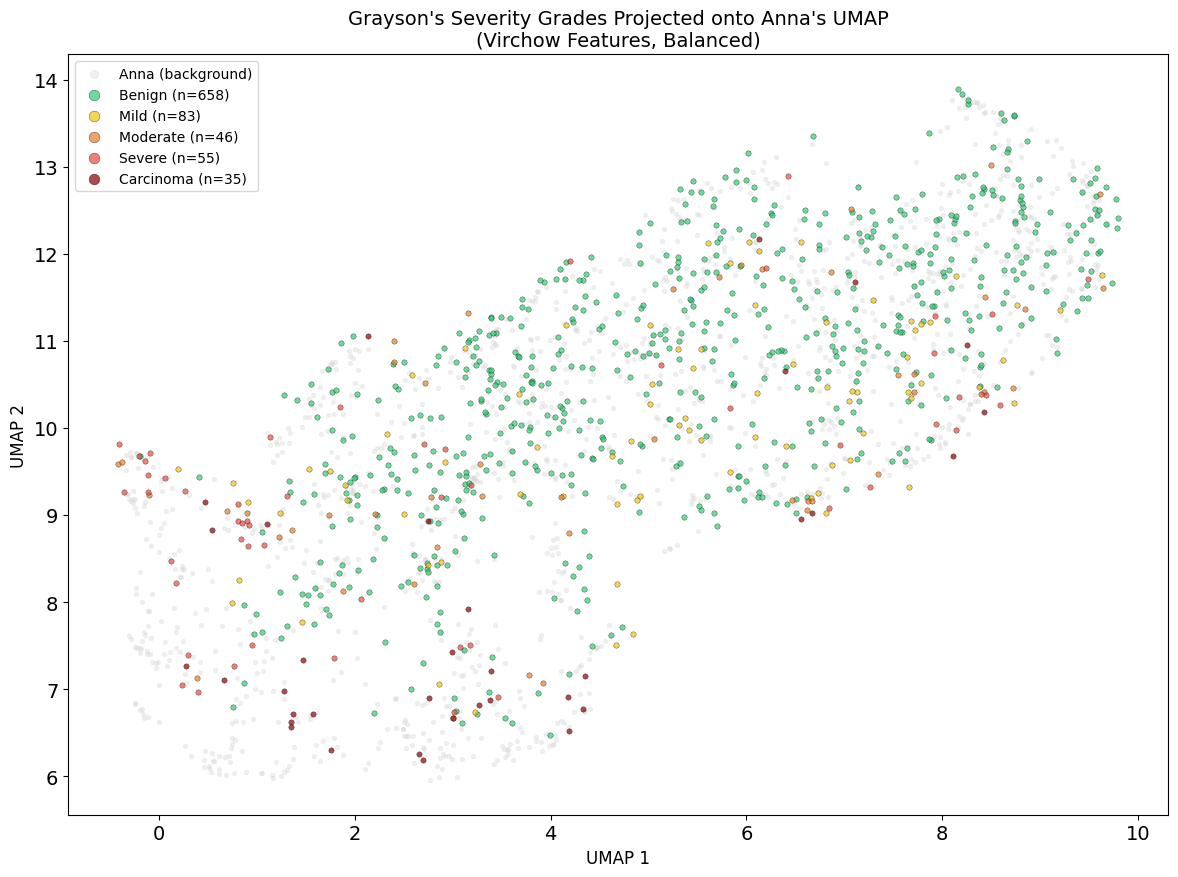

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/grayson_projected_umap.png


In [16]:
import matplotlib.pyplot as plt

# Grayson's severity grades projected onto Anna's UMAP
fig, ax = plt.subplots(figsize=(12, 9))

# Anna's balanced tiles as gray background
ax.scatter(
    balanced_embedding[:, 0],
    balanced_embedding[:, 1],
    c='lightgray',
    alpha=0.3,
    s=8,
    label='Anna (background)',
    zorder=1
)

# Severity grade colors: green -> yellow -> orange -> red -> dark red
severity_colors = {
    'Benign':    '#2ecc71',
    'Mild':      '#f1c40f',
    'Moderate':  '#e67e22',
    'Severe':    '#e74c3c',
    'Carcinoma': '#8b0000',
}

plot_order = ['Benign', 'Mild', 'Moderate', 'Severe', 'Carcinoma']

for label in plot_order:
    mask = g_labels == label
    if mask.sum() == 0:
        continue
    ax.scatter(
        grayson_embedding[mask, 0],
        grayson_embedding[mask, 1],
        c=severity_colors[label],
        label=f'{label} (n={mask.sum()})',
        alpha=0.7,
        s=15,
        edgecolors='black',
        linewidths=0.3,
        zorder=2
    )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title("Grayson's Severity Grades Projected onto Anna's UMAP\n(Virchow Features, Balanced)", fontsize=14)
ax.legend(loc='best', markerscale=2, fontsize=10)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/grayson_projected_umap.png', dpi=200)
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/grayson_projected_umap.png")

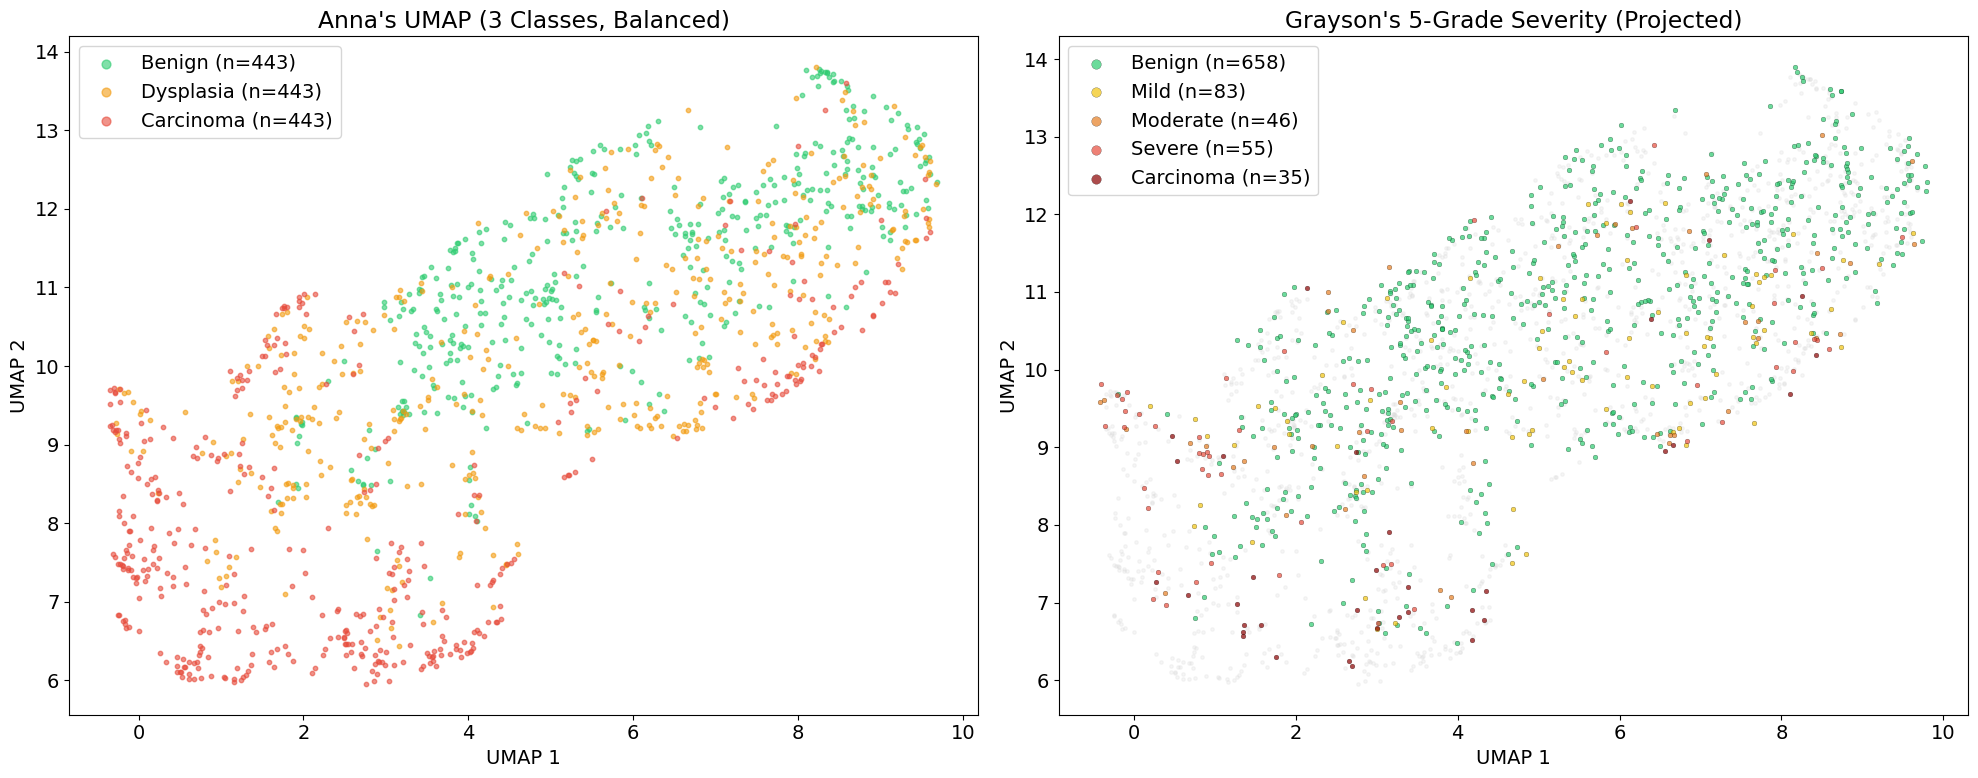

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/comparison_umap.png


In [17]:
# Side-by-side comparison: Anna's 3 classes vs Grayson's 5 severity grades
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left: Anna's original balanced UMAP (3 classes)
anna_colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}
for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    mask = balanced_labels == label
    ax1.scatter(
        balanced_embedding[mask, 0],
        balanced_embedding[mask, 1],
        c=anna_colors[label],
        label=f'{label} (n={mask.sum()})',
        alpha=0.6,
        s=10
    )
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_title("Anna's UMAP (3 Classes, Balanced)")
ax1.legend(loc='best', markerscale=2)

# Right: Grayson's data projected (5 severity grades)
ax2.scatter(
    balanced_embedding[:, 0],
    balanced_embedding[:, 1],
    c='lightgray', alpha=0.2, s=6, zorder=1
)
for label in plot_order:
    mask = g_labels == label
    if mask.sum() == 0:
        continue
    ax2.scatter(
        grayson_embedding[mask, 0],
        grayson_embedding[mask, 1],
        c=severity_colors[label],
        label=f'{label} (n={mask.sum()})',
        alpha=0.7,
        s=12,
        edgecolors='black',
        linewidths=0.2,
        zorder=2
    )
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title("Grayson's 5-Grade Severity (Projected)")
ax2.legend(loc='best', markerscale=2)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/comparison_umap.png', dpi=200)
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/comparison_umap.png")

/tmp/ipykernel_1117942/1210425388.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_g_slides))


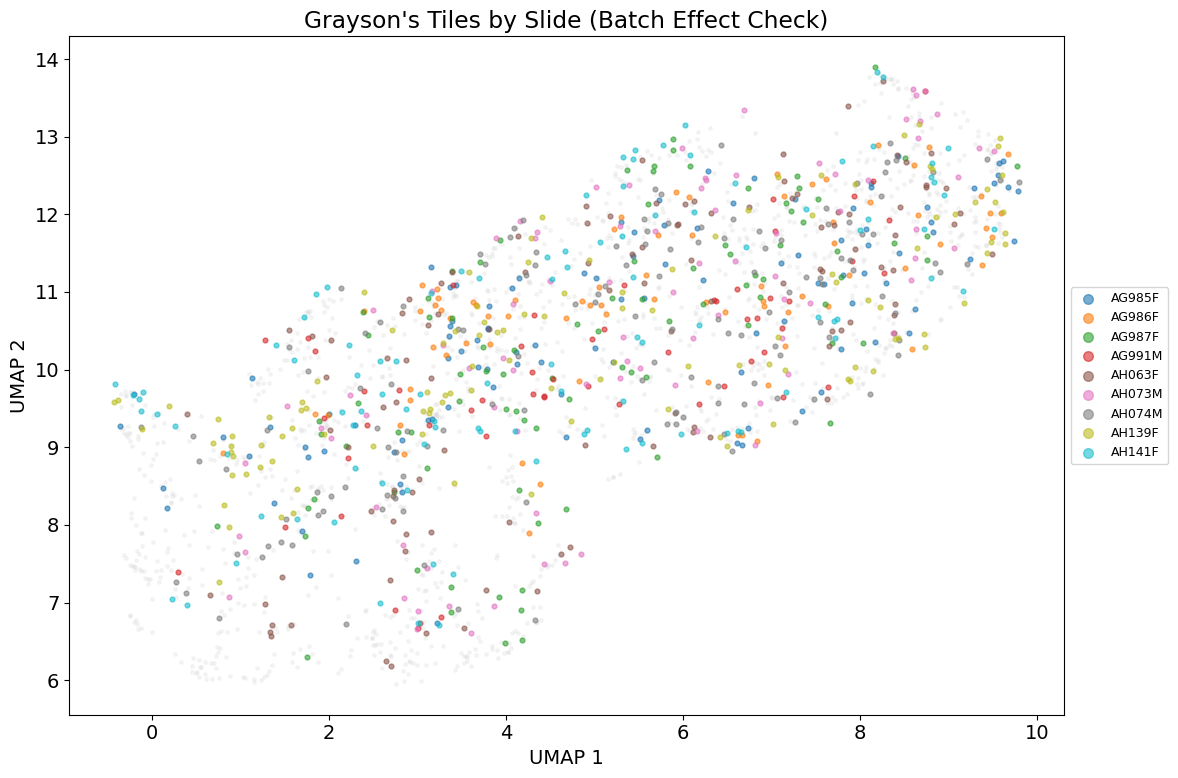

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/grayson_by_slide_umap.png


In [18]:
# Grayson's projected tiles colored by slide (batch effect check)
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(balanced_embedding[:, 0], balanced_embedding[:, 1],
           c='lightgray', alpha=0.2, s=6, zorder=1)

unique_g_slides = np.unique(g_slides)
cmap = plt.cm.get_cmap('tab10', len(unique_g_slides))

for i, slide in enumerate(unique_g_slides):
    mask = g_slides == slide
    ax.scatter(
        grayson_embedding[mask, 0],
        grayson_embedding[mask, 1],
        c=[cmap(i)],
        label=slide,
        alpha=0.6,
        s=12,
        zorder=2
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title("Grayson's Tiles by Slide (Batch Effect Check)")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/grayson_by_slide_umap.png', 
            dpi=200, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/grayson_by_slide_umap.png")

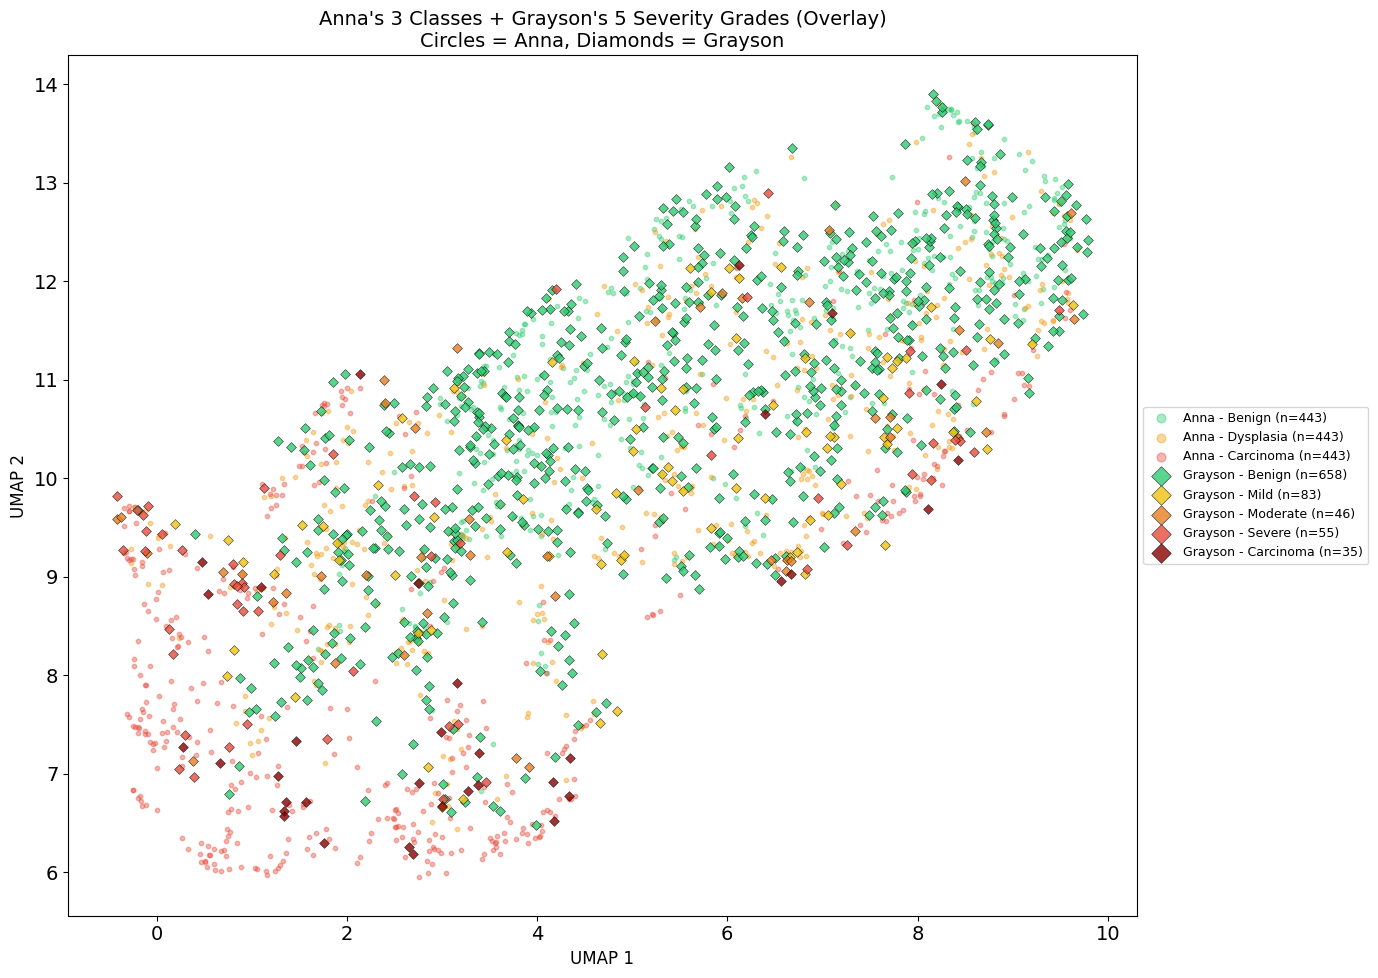

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/overlay_anna_grayson_umap.png


In [19]:
# Combined overlay: Anna's 3 classes + Grayson's 5 severity grades on the same plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot Anna's tiles (circles, no edge) — using her 3-class colors
anna_colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}
for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    mask = balanced_labels == label
    ax.scatter(
        balanced_embedding[mask, 0],
        balanced_embedding[mask, 1],
        c=anna_colors[label],
        label=f'Anna - {label} (n={mask.sum()})',
        alpha=0.4,
        s=10,
        marker='o',
        zorder=1
    )

# Plot Grayson's tiles (diamonds, black edge) — using severity gradient colors
severity_colors = {
    'Benign':    '#2ecc71',
    'Mild':      '#f1c40f',
    'Moderate':  '#e67e22',
    'Severe':    '#e74c3c',
    'Carcinoma': '#8b0000',
}
plot_order = ['Benign', 'Mild', 'Moderate', 'Severe', 'Carcinoma']

for label in plot_order:
    mask = g_labels == label
    if mask.sum() == 0:
        continue
    ax.scatter(
        grayson_embedding[mask, 0],
        grayson_embedding[mask, 1],
        c=severity_colors[label],
        label=f'Grayson - {label} (n={mask.sum()})',
        alpha=0.8,
        s=25,
        marker='D',
        edgecolors='black',
        linewidths=0.4,
        zorder=2
    )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title("Anna's 3 Classes + Grayson's 5 Severity Grades (Overlay)\n"
             "Circles = Anna, Diamonds = Grayson", fontsize=14)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=2, fontsize=9)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/overlay_anna_grayson_umap.png', 
            dpi=200, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/overlay_anna_grayson_umap.png")

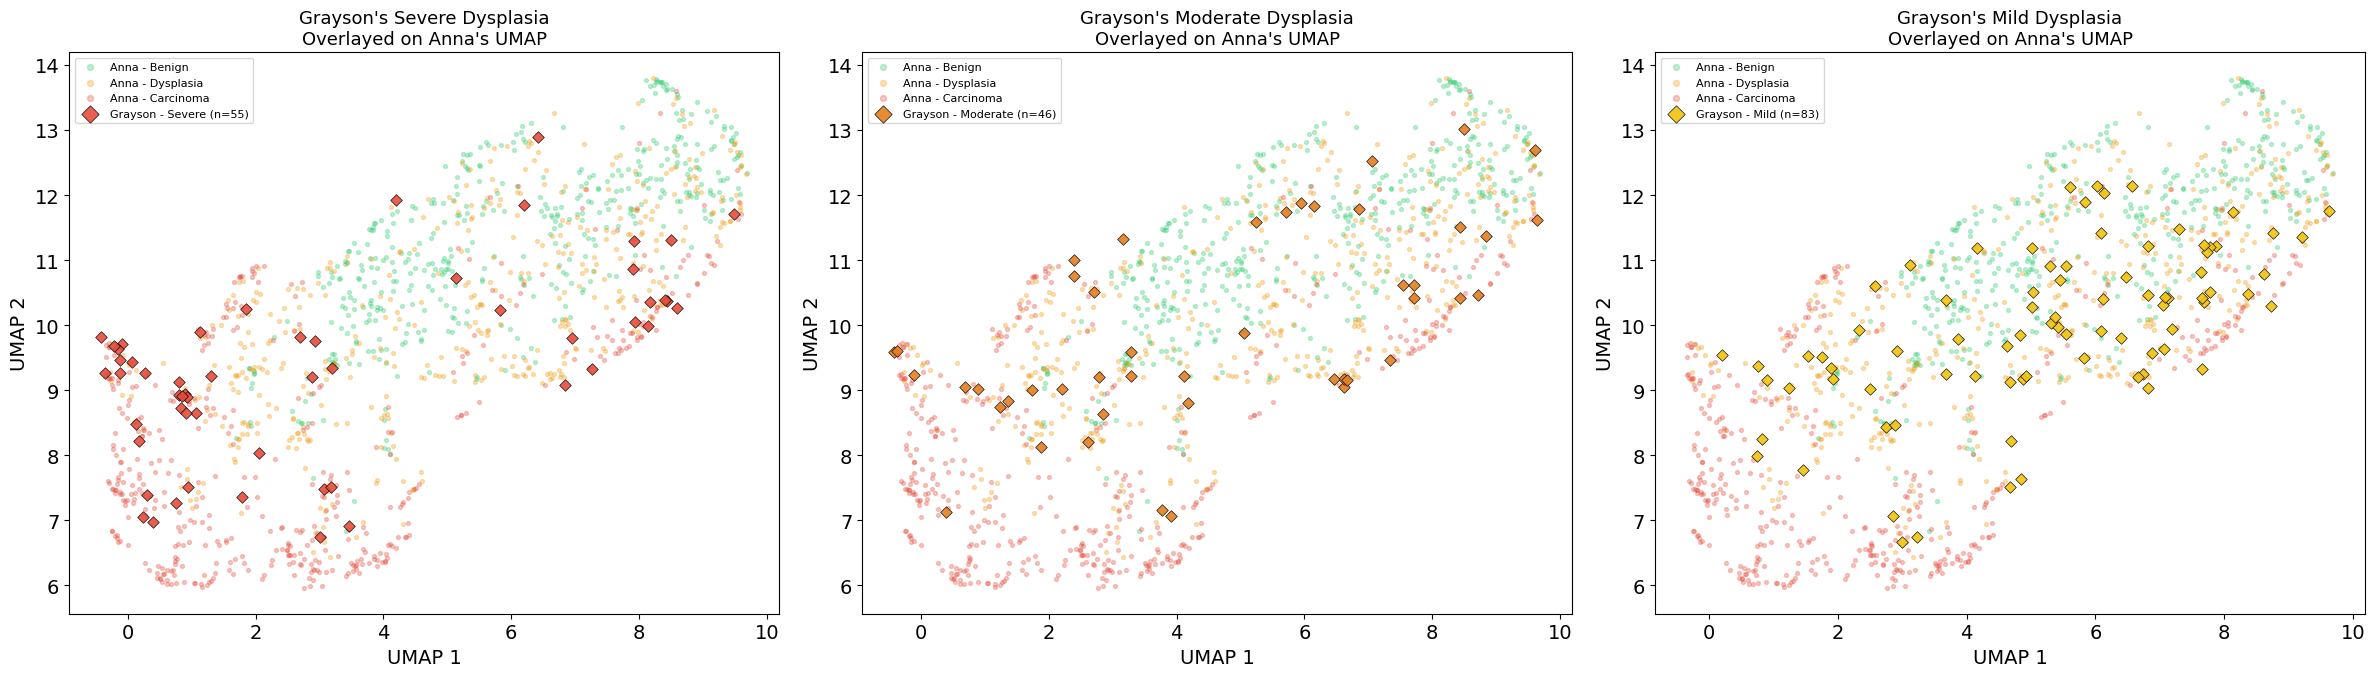

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/individual_grades_overlay.png


In [20]:
# Individual severity grade overlays onto Anna's UMAP
anna_colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}
grayson_grade_color = {'Severe': '#e74c3c', 'Moderate': '#e67e22', 'Mild': '#f1c40f'}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, grade in zip(axes, ['Severe', 'Moderate', 'Mild']):
    # Anna's tiles as background (colored by class)
    for label in ['Benign', 'Dysplasia', 'Carcinoma']:
        mask = balanced_labels == label
        ax.scatter(
            balanced_embedding[mask, 0],
            balanced_embedding[mask, 1],
            c=anna_colors[label],
            label=f'Anna - {label}',
            alpha=0.3,
            s=8,
            marker='o',
            zorder=1
        )
    
    # Grayson's single grade on top
    mask = g_labels == grade
    ax.scatter(
        grayson_embedding[mask, 0],
        grayson_embedding[mask, 1],
        c=grayson_grade_color[grade],
        label=f'Grayson - {grade} (n={mask.sum()})',
        alpha=0.9,
        s=35,
        marker='D',
        edgecolors='black',
        linewidths=0.5,
        zorder=2
    )
    
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f"Grayson's {grade} Dysplasia\nOverlayed on Anna's UMAP", fontsize=13)
    ax.legend(loc='best', markerscale=1.5, fontsize=8)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/individual_grades_overlay.png', 
            dpi=200, bbox_inches='tight')
plt.show()

print("Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/individual_grades_overlay.png")

## Proportional Downsampling (Slide-Aware)

Improved downsampling strategy that distributes tile removal proportionally across slides within each class.
A minimum floor protects slides with very few tiles from being wiped out entirely.
After proportional sampling, a final random trim brings each class to the exact target if needed.

In [4]:
import pandas as pd
import numpy as np

MIN_FLOOR = 5       # Minimum tiles to keep from any slide for a given class
TARGET_N = 443      # Target number of tiles per class (size of smallest class)

# Build DataFrame from existing arrays
results_df = pd.DataFrame({'label': all_labels, 'slide': all_slides})
results_df['feature_idx'] = np.arange(len(all_features))

balanced_dfs = []

for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    class_df = results_df[results_df['label'] == label].copy()
    total_class = len(class_df)

    if total_class <= TARGET_N:
        # Already at or below target — keep all
        balanced_dfs.append(class_df)
        print(f'{label}: {total_class} tiles (no downsampling needed)')
        continue

    # Proportional sampling per slide with floor protection
    slide_samples = []
    for slide, slide_df in class_df.groupby('slide'):
        n_slide = len(slide_df)
        target_from_slide = round(n_slide * TARGET_N / total_class)
        keep = min(n_slide, max(target_from_slide, MIN_FLOOR))
        sampled = slide_df.sample(n=keep, random_state=42)
        slide_samples.append(sampled)

    prop_df = pd.concat(slide_samples, ignore_index=True)
    print(f'{label}: {total_class} → {len(prop_df)} tiles after proportional sampling', end='')

    # Final trim if we're still over TARGET_N (due to floor protection)
    if len(prop_df) > TARGET_N:
        prop_df = prop_df.sample(n=TARGET_N, random_state=42)
        print(f' → {len(prop_df)} after final trim')
    else:
        print()  # newline

    balanced_dfs.append(prop_df)

balanced_df = pd.concat(balanced_dfs, ignore_index=True)
balanced_indices = balanced_df['feature_idx'].values
balanced_features = all_features[balanced_indices]
balanced_labels = balanced_df['label'].values
balanced_slides = balanced_df['slide'].values

print(f'\nFinal class counts:')
print(balanced_df['label'].value_counts())
print(f'\nSlide representation per class:')
print(balanced_df.groupby(['label', 'slide']).size().unstack(fill_value=0))

Benign: 453 → 445 tiles after proportional sampling → 443 after final trim
Dysplasia: 1137 → 444 tiles after proportional sampling → 443 after final trim
Carcinoma: 443 tiles (no downsampling needed)

Final class counts:
label
Benign       443
Dysplasia    443
Carcinoma    443
Name: count, dtype: int64

Slide representation per class:
slide      AG985F  AG986F  AG987F  AG991M  AH063F  AH073M  AH074M  AH139F  \
label                                                                       
Benign         20      55      21      17       7      15      16      27   
Carcinoma       9       4       8      22      16       0      21      16   
Dysplasia      33      11      24       8      34      28      39      26   

slide      AH141F  AH142F  AH145M  AH146M  AH210F  AH211F  AH212F  AH213F  \
label                                                                       
Benign         31      22      38       0      52      34      37      47   
Carcinoma      14      11      20      44     

In [5]:
import umap

# Run UMAP on proportionally downsampled features
print('Running UMAP on proportionally downsampled data...')

reducer_prop = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

prop_embedding = reducer_prop.fit_transform(balanced_features)
print(f'UMAP complete! Shape: {prop_embedding.shape}')

Running UMAP on proportionally downsampled data...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete! Shape: (1329, 2)


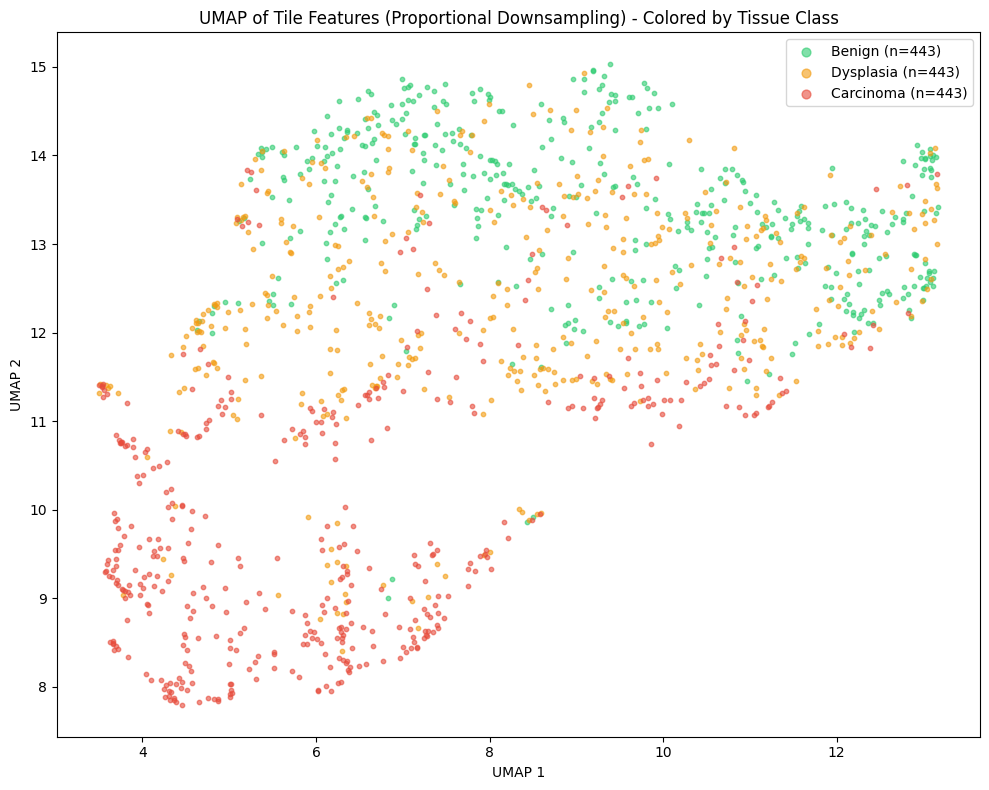

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_prop_by_class.png


In [6]:
import matplotlib.pyplot as plt

# Plot proportional UMAP colored by tissue class
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}

for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    mask = balanced_labels == label
    ax.scatter(
        prop_embedding[mask, 0],
        prop_embedding[mask, 1],
        c=colors[label],
        label=f'{label} (n={mask.sum()})',
        alpha=0.6,
        s=10
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of Tile Features (Proportional Downsampling) - Colored by Tissue Class')
ax.legend(loc='best', markerscale=2)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_prop_by_class.png', dpi=150)
plt.show()
print('Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_prop_by_class.png')

/tmp/ipykernel_31419/1438333949.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_slides))


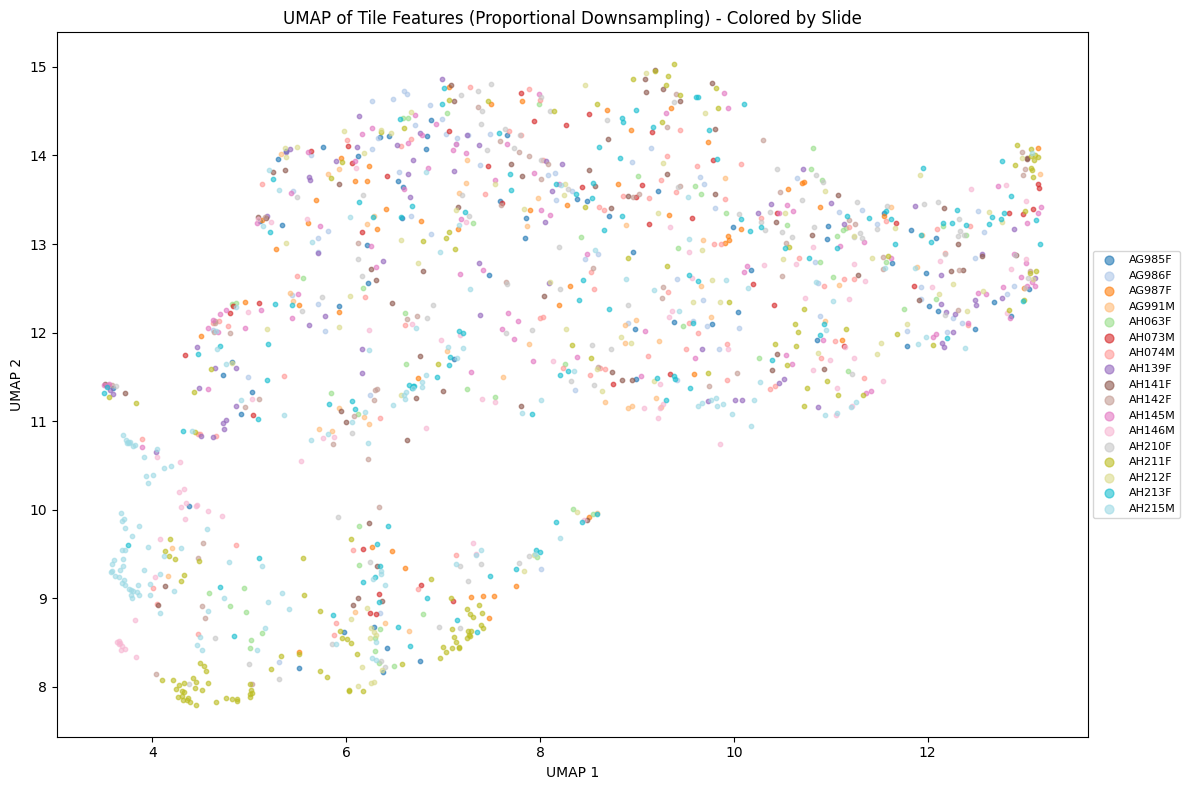

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_prop_by_slide.png


In [7]:
# Plot proportional UMAP colored by slide (batch effect check)
fig, ax = plt.subplots(figsize=(12, 8))

unique_slides = np.unique(balanced_slides)
cmap = plt.cm.get_cmap('tab20', len(unique_slides))

for i, slide in enumerate(unique_slides):
    mask = balanced_slides == slide
    ax.scatter(
        prop_embedding[mask, 0],
        prop_embedding[mask, 1],
        c=[cmap(i)],
        label=slide,
        alpha=0.6,
        s=10
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of Tile Features (Proportional Downsampling) - Colored by Slide')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_prop_by_slide.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_prop_by_slide.png')

## Independent Validation: Grayson's Non-Overlapping Slides

Anna and Grayson annotated the same 9 slides covering nearly identical tissue regions — they disagreed on labels, not location.
This raises a concern: tiles from overlapping slides may share the same physical tissue, making the projection circular.

To address this, we use Grayson's **15 non-overlapping slides** (never seen by Anna or used during UMAP fitting):
- 14 Exp1 AF* slides
- 1 Exp2 slide (AH072M)

If Grayson's Severe tiles cluster near Anna's Carcinoma region on these slides, that is genuine generalization.

### Step 1: Extract Tiles from Non-Overlapping Slides

In [9]:
import slideflow as sf
from slideflow.slide import qc

PROJECT_PATH = '/home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo'
project = sf.load_project(PROJECT_PATH)

# Extract tiles from the 15 non-overlapping Grayson slides
# annotations.csv now contains only these 15 slides
#Print out dataset
dataset = project.dataset(sources=['Grayson_Dataset'])
dataset.summary()

Overview:
╒═════════════════════╤════════════════════════════════════════════════════════════════════════╕
│ Configuration file: │ /home/stanna/labshare/PERSONAL/stanna/PROJECTS/Exp2_Demo/datasets.json │
│ Tile size (px):     │                                                                        │
│ Tile size (um):     │                                                                        │
│ Slides:             │ 15                                                                     │
│ Patients:           │ 15                                                                     │
│ Slides with ROIs:   │ 15                                                                     │
│ Patients with ROIs: │ 15                                                                     │
╘═════════════════════╧════════════════════════════════════════════════════════════════════════╛

Filters:
╒═══════════════╤════╕
│ Filters:      │ {} │
├───────────────┼────┤
│ Filter Blank: │ [] │
├──────────────

In [11]:

# Extract tiles from the 15 non-overlapping Grayson slides
# annotations.csv now contains only these 15 slides
project.extract_tiles(
    tile_px=299,
    tile_um=302,
    roi_method='inside',
    whitespace_fraction=0.95,
    source=['Grayson_Dataset'],
    qc=[qc.GaussianV2(), qc.Otsu()]
)

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[02:51:55] INFO     Slide reading backend: cucim

           INFO     Filtering tiles by whitespace fraction

           INFO     Filtering tiles by grayspace fraction

           INFO     Working on dataset source Grayson_Dataset...

...

           INFO     Generating PDF (this may take some time)...

/tmp/ipykernel_31419/3029713501.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  project.extract_tiles(
/tmp/ipykernel_31419/3029713501.py:3: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  project.extract_tiles(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
/tmp/ipykernel_31419/3029713501.py:3: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=0 use new_x=XPos.RIGHT, new_y=YPos.TOP.
  project.extract_tiles(
/tmp/ipykernel_31419/3029713501.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soo

Updating CSV for 15 reports.


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

{'/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF107.svs': <slideflow.slide.report.SlideReport at 0x7b4b17565820>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF110F.svs': <slideflow.slide.report.SlideReport at 0x7b4b175682e0>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF104.svs': <slideflow.slide.report.SlideReport at 0x7b4b17568b20>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF238F.svs': <slideflow.slide.report.SlideReport at 0x7b4b17568f40>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF136M.svs': <slideflow.slide.report.SlideReport at 0x7b4b17568d60>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF252.svs': <slideflow.slide.report.SlideReport at 0x7b4b17568af0>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF257M.svs': <slideflow.slide.report.SlideReport at 0x7b4a258dbcd0>,
 '/home/stanna/labshare/SLIDES/PDCD10/TAM_then_4NQO/AF130F.svs': <slideflow.slide.report.SlideReport at 0x7b4a258dbb50>,
 '/home/stanna/labshare/SLIDES/PDCD

### Step 2: Extract Virchow Features

In [14]:
# Extract Virchow features for the 15 non-overlapping slides
# Features saved to the same Grayson feature directory
INDEP_FEATURE_DIR = '/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/features/virchow'

indep_dataset = project.dataset(
    sources=['Grayson_Dataset'],
    tile_px=299,
    tile_um=302
)

indep_dataset.generate_feature_bags(extractor, outdir=INDEP_FEATURE_DIR)

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[02:58:45] INFO     Using feature extractor: virchow

[02:58:46] INFO     Working on 15 slides

### Step 3: Load Features and Map to Grayson's Labels

In [15]:
import numpy as np
import pandas as pd
import torch
from shapely.geometry import Point, Polygon
from pathlib import Path

INDEP_FEATURE_DIR = Path('/home/stanna/labshare/PERSONAL/stanna/DATA/Grayson/features/virchow')
GRAYSON_ROI_DIR = Path('/home/stanna/labshare/PROJECTS/PDCD10/rois/grayson')

# The 15 non-overlapping slides
INDEP_SLIDES = [
    'AH072M',
    'AF102F', 'AF104', 'AF107', 'AF109', 'AF110F', 'AF113M',
    'AF130F', 'AF135M', 'AF136M', 'AF238F', 'AF239F',
    'AF252', 'AF254F', 'AF257M'
]

VALID_LABELS = {'Benign', 'Mild', 'Moderate', 'Severe', 'Carcinoma'}

def load_grayson_roi_polygons(slide_name):
    roi_path = GRAYSON_ROI_DIR / f'{slide_name}.csv'
    if not roi_path.exists():
        print(f'Warning: ROI file not found for {slide_name}')
        return []
    df = pd.read_csv(roi_path)
    polygons = []
    for roi_name, group in df.groupby('roi_name'):
        coords = list(zip(group['x_base'], group['y_base']))
        if len(coords) >= 3:
            try:
                label_val = group['label'].iloc[0] if 'label' in group.columns else 'Unknown'
                poly = Polygon(coords)
                if poly.is_valid and label_val in VALID_LABELS:
                    polygons.append((poly, label_val))
            except Exception:
                pass
    return polygons

indep_features = []
indep_labels = []
indep_slides = []

for slide in INDEP_SLIDES:
    pt_path = INDEP_FEATURE_DIR / f'{slide}.pt'
    idx_path = INDEP_FEATURE_DIR / f'{slide}.index.npz'
    if not pt_path.exists() or not idx_path.exists():
        print(f'Skipping {slide}: feature files not found')
        continue

    features = torch.load(pt_path).numpy()
    idx = np.load(idx_path)
    coords = idx['arr_0']
    polygons = load_grayson_roi_polygons(slide)

    if not polygons:
        print(f'Skipping {slide}: no valid ROIs')
        continue

    for i, (x, y) in enumerate(coords):
        point = Point(x, y)
        assigned_label = None
        for poly, label in polygons:
            if poly.contains(point):
                assigned_label = label
                break
        if assigned_label is not None:
            indep_features.append(features[i])
            indep_labels.append(assigned_label)
            indep_slides.append(slide)

indep_features = np.array(indep_features)
indep_labels = np.array(indep_labels)
indep_slides = np.array(indep_slides)

print(f'Total tiles loaded: {len(indep_features)}')
print('Label distribution:')
for lbl, count in zip(*np.unique(indep_labels, return_counts=True)):
    print(f'  {lbl}: {count}')

/tmp/ipykernel_31419/2601258292.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()
/tmp/ipykernel_31419/2601258292.py:50: FutureWarn

Total tiles loaded: 944
Label distribution:
  Benign: 765
  Carcinoma: 121
  Mild: 43
  Moderate: 8
  Severe: 7


/tmp/ipykernel_31419/2601258292.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(pt_path).numpy()


### Step 4: Project onto Anna's UMAP

In [16]:
import joblib

# Load saved reducer (fit on Anna's balanced data)
reducer = joblib.load('/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_reducer_balanced.joblib')

print('Projecting independent Grayson slides onto Anna\'s UMAP...')
indep_embedding = reducer.transform(indep_features)
print(f'Embedding shape: {indep_embedding.shape}')

Projecting independent Grayson slides onto Anna's UMAP...


/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Embedding shape: (944, 2)


### Step 5: Visualize

/home/stanna/miniconda3/envs/SF/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


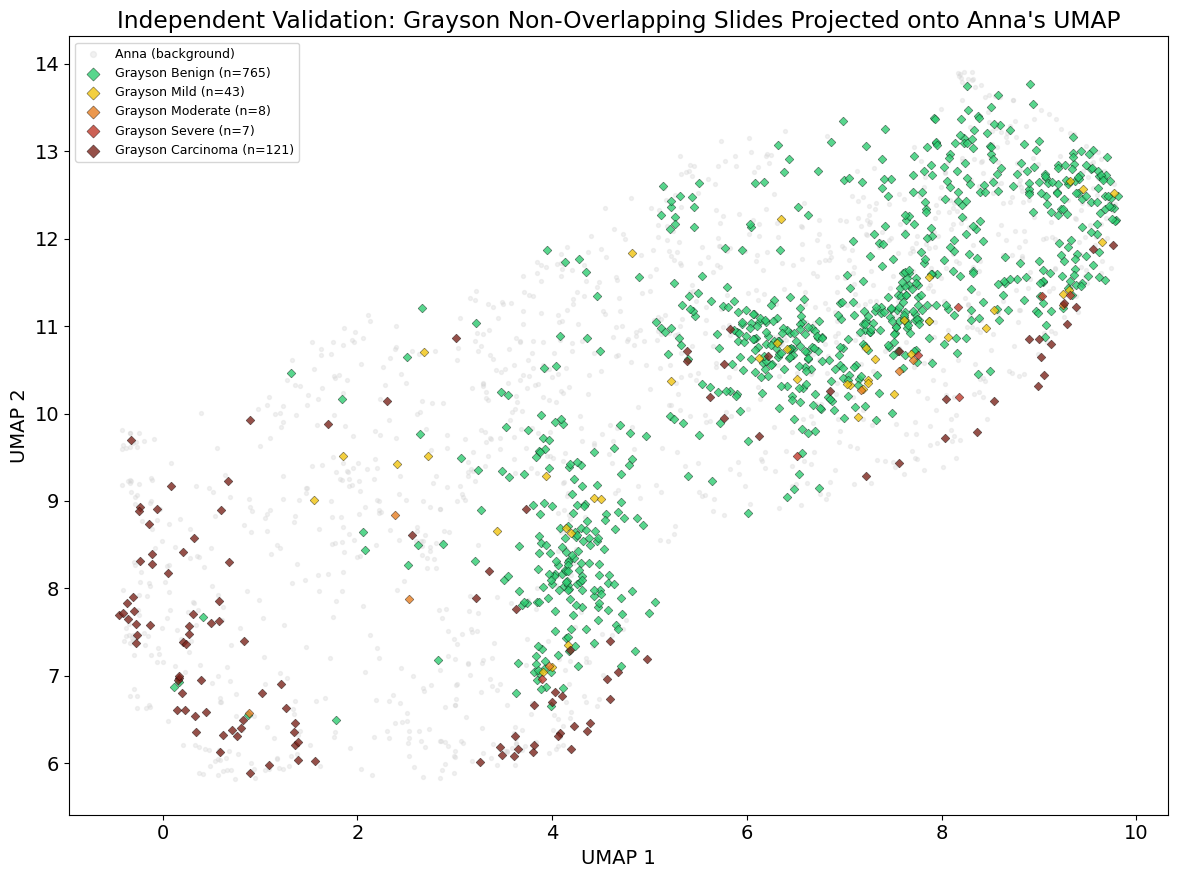

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_indep_grayson_projection.png


In [18]:
import matplotlib.pyplot as plt

severity_colors = {
    'Benign':   '#2ecc71',
    'Mild':     '#f1c40f',
    'Moderate': '#e67e22',
    'Severe':   '#c0392b',
    'Carcinoma':'#7b241c'
}

# Reproject Anna's balanced features into the same coordinate space as indep_embedding
anna_background_embedding = reducer.transform(balanced_features)

fig, ax = plt.subplots(figsize=(12, 9))

# Anna's tiles as gray background
ax.scatter(
    anna_background_embedding[:, 0], anna_background_embedding[:, 1],
    c='lightgray', alpha=0.3, s=8, label='Anna (background)', zorder=1
)

# Independent Grayson slides colored by severity grade
for grade in ['Benign', 'Mild', 'Moderate', 'Severe', 'Carcinoma']:
    mask = indep_labels == grade
    if mask.sum() == 0:
        continue
    ax.scatter(
        indep_embedding[mask, 0], indep_embedding[mask, 1],
        c=severity_colors[grade],
        label=f'Grayson {grade} (n={mask.sum()})',
        alpha=0.8, s=20,
        marker='D', edgecolors='black', linewidths=0.3,
        zorder=2
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Independent Validation: Grayson Non-Overlapping Slides Projected onto Anna\'s UMAP')
ax.legend(loc='best', markerscale=1.5, fontsize=9)

plt.tight_layout()
SAVE_PATH = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_indep_grayson_projection.png'
plt.savefig(SAVE_PATH, dpi=150)
plt.show()
print(f'Figure saved to: {SAVE_PATH}')

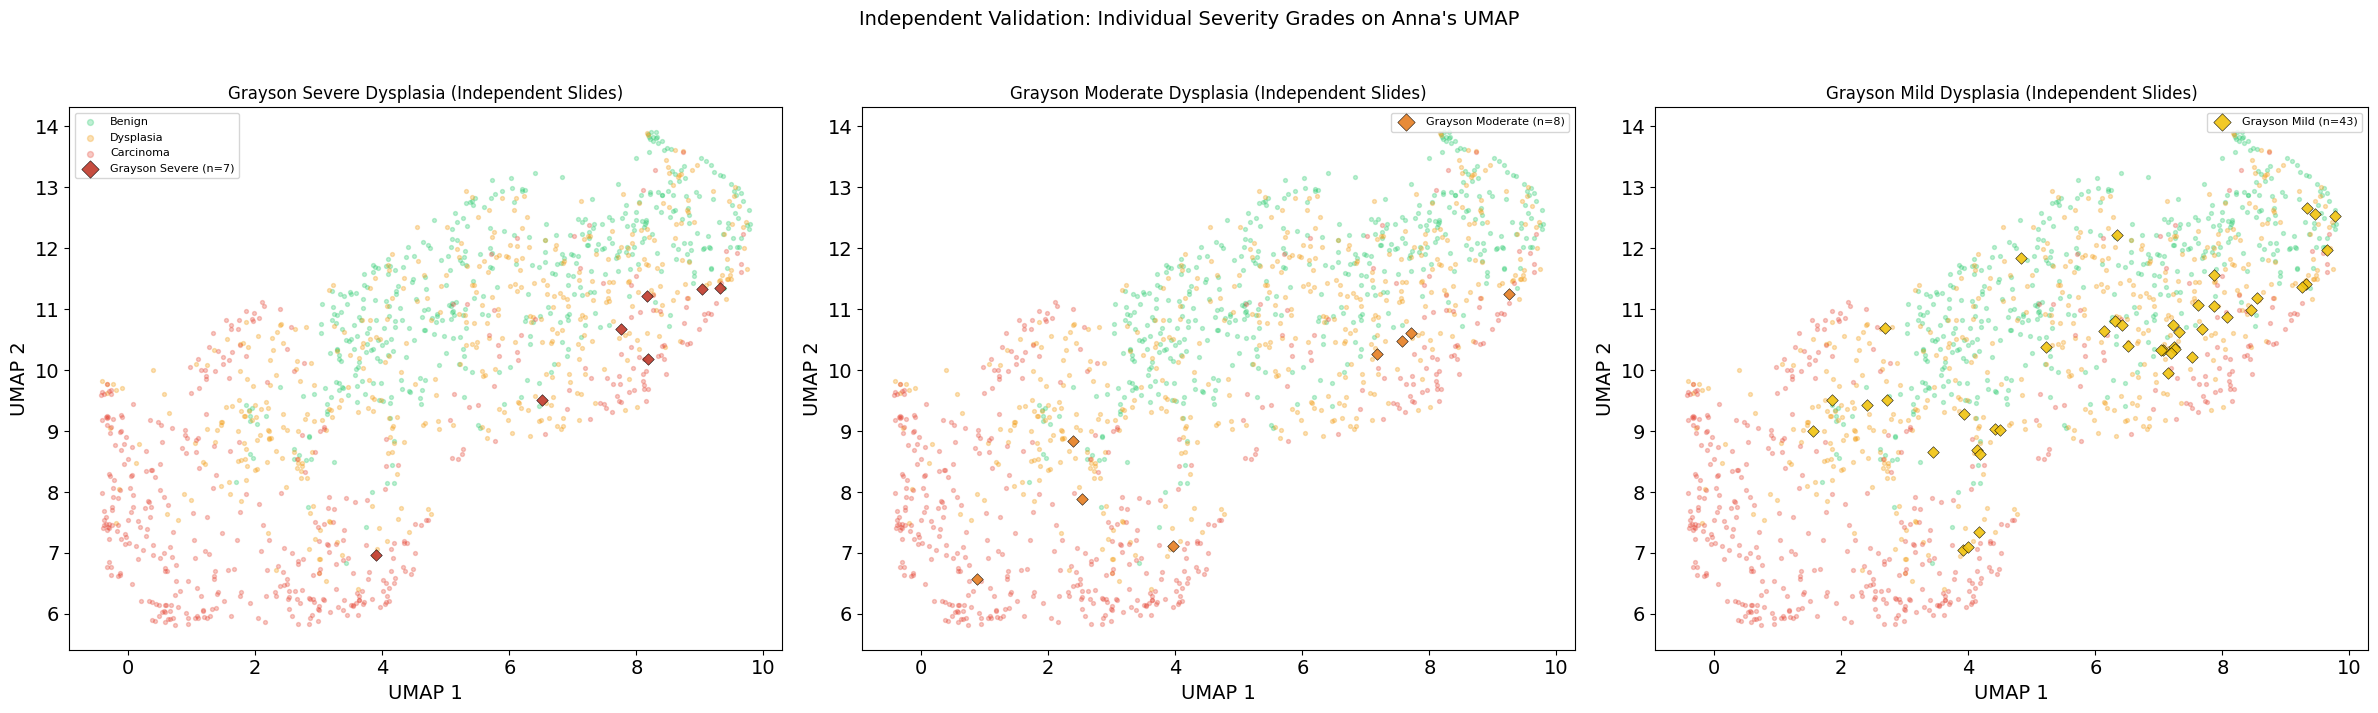

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_indep_individual_grades.png


In [19]:
# Individual severity grade overlays: Severe, Moderate, Mild each on Anna's UMAP
anna_colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}
grade_colors = {'Severe': '#c0392b', 'Moderate': '#e67e22', 'Mild': '#f1c40f'}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, grade in zip(axes, ['Severe', 'Moderate', 'Mild']):
    # Anna's tiles as background colored by class
    for label in ['Benign', 'Dysplasia', 'Carcinoma']:
        mask = balanced_labels == label
        ax.scatter(
            anna_background_embedding[mask, 0],
            anna_background_embedding[mask, 1],
            c=anna_colors[label],
            alpha=0.3, s=8, label=label if grade == 'Severe' else '_nolegend_',
            zorder=1
        )

    # Single Grayson grade on top
    mask = indep_labels == grade
    ax.scatter(
        indep_embedding[mask, 0],
        indep_embedding[mask, 1],
        c=grade_colors[grade],
        label=f'Grayson {grade} (n={mask.sum()})',
        alpha=0.9, s=35,
        marker='D', edgecolors='black', linewidths=0.4,
        zorder=2
    )

    ax.set_title(f'Grayson {grade} Dysplasia (Independent Slides)', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(loc='best', markerscale=1.5, fontsize=8)

plt.suptitle('Independent Validation: Individual Severity Grades on Anna\'s UMAP', fontsize=14, y=1.02)
plt.tight_layout()
SAVE_PATH = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_indep_individual_grades.png'
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to: {SAVE_PATH}')

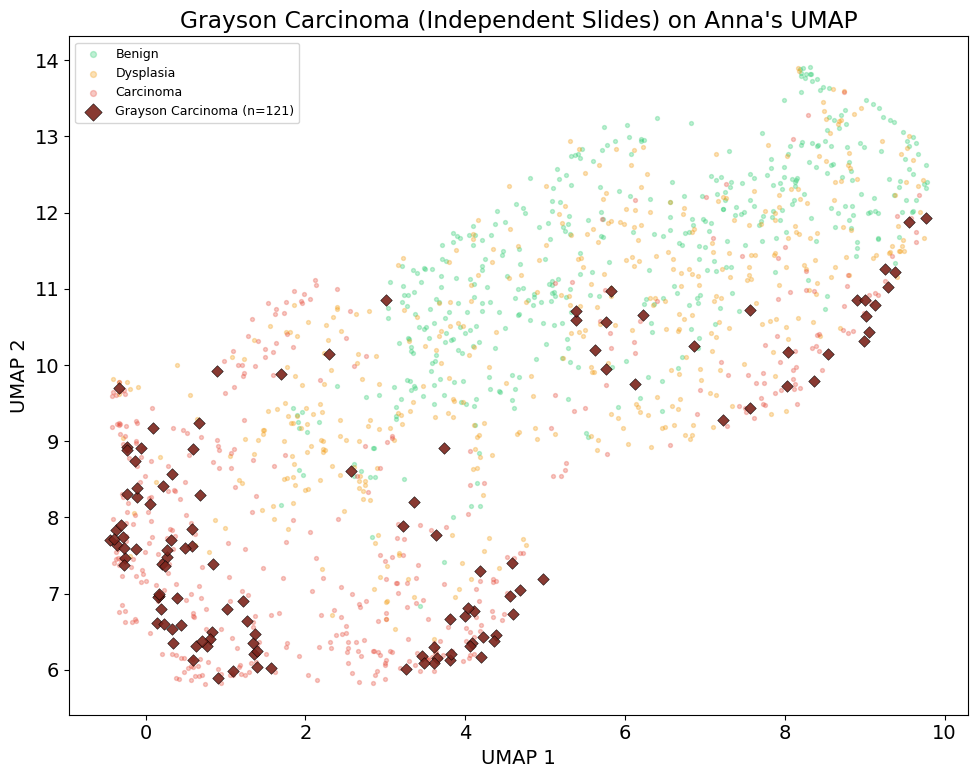

Figure saved to: /home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_indep_carcinoma_overlay.png


In [20]:
# Grayson's Carcinoma (independent slides) overlaid on Anna's UMAP
fig, ax = plt.subplots(figsize=(10, 8))

anna_colors = {'Benign': '#2ecc71', 'Dysplasia': '#f39c12', 'Carcinoma': '#e74c3c'}

for label in ['Benign', 'Dysplasia', 'Carcinoma']:
    mask = balanced_labels == label
    ax.scatter(
        anna_background_embedding[mask, 0],
        anna_background_embedding[mask, 1],
        c=anna_colors[label],
        alpha=0.3, s=8, label=label, zorder=1
    )

mask = indep_labels == 'Carcinoma'
ax.scatter(
    indep_embedding[mask, 0],
    indep_embedding[mask, 1],
    c='#7b241c',
    label=f'Grayson Carcinoma (n={mask.sum()})',
    alpha=0.9, s=35,
    marker='D', edgecolors='black', linewidths=0.4,
    zorder=2
)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Grayson Carcinoma (Independent Slides) on Anna\'s UMAP')
ax.legend(loc='best', markerscale=1.5, fontsize=9)

plt.tight_layout()
SAVE_PATH = '/home/stanna/labshare/PERSONAL/stanna/DATA/Exp2/features/umap_indep_carcinoma_overlay.png'
plt.savefig(SAVE_PATH, dpi=150)
plt.show()
print(f'Figure saved to: {SAVE_PATH}')